# Imports

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from src.data.loader import load_story_dataset

RANDOM_STATE = 42
N_SPLITS = 5

d:\work\cyshield_Task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load the cleaned corpus

In [2]:
dataset = load_story_dataset(filter_malformed=True)

df = dataset[
    ["id", "title", "story", "genre"]
].copy()

df["id"] = df["id"].astype(str)

print(f"Stories: {len(df)}")
print(f"Genres: {df['genre'].nunique()}")
print(f"Missing stories: {df['story'].isna().sum()}")
print(f"Missing genres: {df['genre'].isna().sum()}")
print(f"Duplicate IDs: {df['id'].duplicated().sum()}")

df.head()

Excluding 1 malformed story sample(s): ['308506']
Stories: 999
Genres: 99
Missing stories: 0
Missing genres: 0
Duplicate IDs: 0


,id,title,story,genre
0,457580,The Chronicles of the Cosmic Rift,"In the year 2250, Earth had made significant s...",Science Fiction
1,297904,Eldoria's Enchanted Whispers,"In a land far away, where the sun shone bright...",Fantasy
2,620436,Echoes of Whispered Shadows,"Once upon a time, in a small, tranquil town ca...",Mystery
3,634687,Emerald Amulet Chronicles Revealed,"Once upon a time in the 16th century, a small ...",Historical Adventure
4,513427,The Shadows of St. Augustine,In the sun-drenched coastal city of St. August...,Thriller


## Verifing class distribution

In [3]:
genre_counts = (
    df["genre"]
    .value_counts()
    .sort_values(ascending=False)
)

display(genre_counts.to_frame("count"))

print("\nClass distribution summary:")
display(genre_counts.describe())

,count
genre,
Historical Adventure,20
Science Fiction,10
Mystery,10
Thriller,10
Historical Fiction,10
...,...
Steampunk Fantasy,10
Noir Comedy,10
Social Commentary,10



Class distribution summary:


count    99.000000
mean     10.090909
std       1.011070
min       9.000000
25%      10.000000
50%      10.000000
75%      10.000000
max      20.000000
Name: count, dtype: float64

In [4]:
print("Minimum samples/class:", genre_counts.min())
print("Maximum samples/class:", genre_counts.max())

print("\nClasses with non-standard counts:")
display(
    genre_counts[
        genre_counts != genre_counts.mode().iloc[0]
    ]
)

Minimum samples/class: 9
Maximum samples/class: 20

Classes with non-standard counts:


genre
Historical Adventure    20
Fantasy                  9
Name: count, dtype: int64

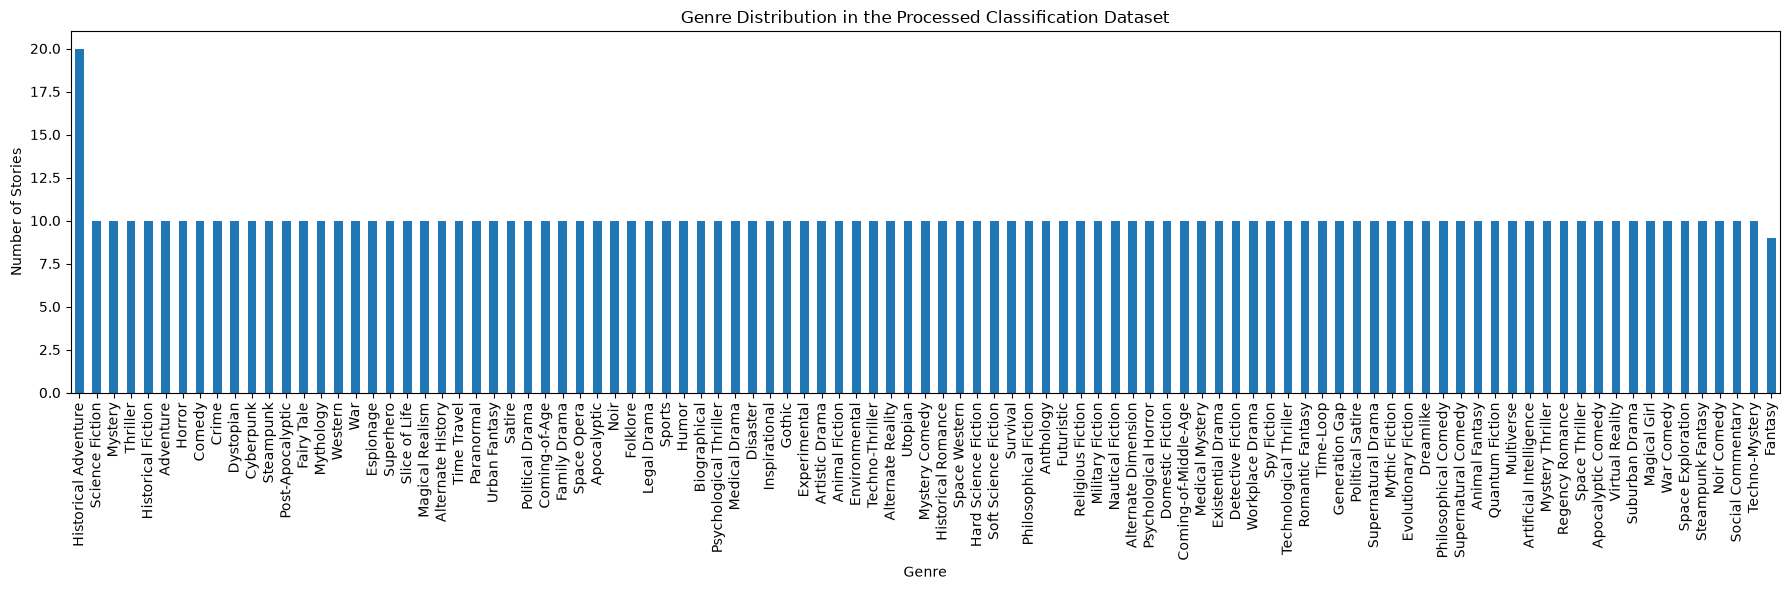

In [5]:
plt.figure(figsize=(18, 6))
genre_counts.plot(kind="bar")

plt.title("Genre Distribution in the Processed Classification Dataset")
plt.xlabel("Genre")
plt.ylabel("Number of Stories")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
X = df["story"].astype(str).values
y = df["genre"].astype(str).values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (999,)
y shape: (999,)


In [7]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

fold_sizes = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
    train_labels = pd.Series(y[train_idx])
    val_labels = pd.Series(y[val_idx])

    fold_sizes.append({
        "fold": fold,
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        "train_classes": train_labels.nunique(),
        "val_classes": val_labels.nunique(),
        "min_train_per_class": train_labels.value_counts().min(),
        "min_val_per_class": val_labels.value_counts().min(),
        "max_val_per_class": val_labels.value_counts().max(),
    })

fold_summary = pd.DataFrame(fold_sizes)
fold_summary

,fold,train_size,val_size,train_classes,val_classes,min_train_per_class,min_val_per_class,max_val_per_class
0,1,799,200,99,99,7,2,4
1,2,799,200,99,99,7,2,4
2,3,799,200,99,99,7,2,4
3,4,799,200,99,99,7,2,4
4,5,800,199,99,99,8,1,4


# TF-IDF + LinearSVC baseline

In [8]:
fold_results = []
oof_predictions = np.empty(len(df), dtype=object)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
    print(f"\n{'=' * 60}")
    print(f"Fold {fold}/{N_SPLITS}")
    print(f"{'=' * 60}")

    X_train = X[train_idx]
    X_val = X[val_idx]

    y_train = y[train_idx]
    y_val = y[val_idx]

    # --------------------------------
    # TF-IDF
    # --------------------------------
    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_features=50_000,
        sublinear_tf=True,
    )

    start = time.perf_counter()

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_val_tfidf = vectorizer.transform(X_val)

    vectorization_time = time.perf_counter() - start

    # --------------------------------
    # Classifier
    # --------------------------------
    classifier = LinearSVC(
        C=1.0,
    )

    start = time.perf_counter()
    classifier.fit(X_train_tfidf, y_train)
    training_time = time.perf_counter() - start

    # --------------------------------
    # Inference
    # --------------------------------
    start = time.perf_counter()
    y_pred = classifier.predict(X_val_tfidf)
    inference_time = time.perf_counter() - start

    oof_predictions[val_idx] = y_pred

    # --------------------------------
    # Metrics
    # --------------------------------
    metrics = {
        "fold": fold,
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_precision": precision_score(
            y_val,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "macro_recall": recall_score(
            y_val,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "macro_f1": f1_score(
            y_val,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_val,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "num_features": X_train_tfidf.shape[1],
        "vectorization_time_s": vectorization_time,
        "training_time_s": training_time,
        "inference_time_s": inference_time,
        "latency_per_story_ms": (
            inference_time / len(val_idx)
        ) * 1000,
    }

    fold_results.append(metrics)

    print(f"Features:       {metrics['num_features']:,}")
    print(f"Accuracy:       {metrics['accuracy']:.4f}")
    print(f"Macro F1:       {metrics['macro_f1']:.4f}")
    print(f"Weighted F1:    {metrics['weighted_f1']:.4f}")
    print(f"Training time:  {metrics['training_time_s']:.3f}s")
    print(
        f"Inference:      "
        f"{metrics['latency_per_story_ms']:.3f} ms/story"
    )


Fold 1/5
Features:       50,000
Accuracy:       0.5650
Macro F1:       0.5322
Weighted F1:    0.5330
Training time:  2.340s
Inference:      0.241 ms/story

Fold 2/5
Features:       50,000
Accuracy:       0.6350
Macro F1:       0.6055
Weighted F1:    0.6054
Training time:  2.570s
Inference:      0.141 ms/story

Fold 3/5
Features:       50,000
Accuracy:       0.6450
Macro F1:       0.6097
Weighted F1:    0.6086
Training time:  2.323s
Inference:      0.135 ms/story

Fold 4/5
Features:       50,000
Accuracy:       0.5800
Macro F1:       0.5396
Weighted F1:    0.5392
Training time:  2.472s
Inference:      0.126 ms/story

Fold 5/5
Features:       50,000
Accuracy:       0.5879
Macro F1:       0.5286
Weighted F1:    0.5321
Training time:  2.270s
Inference:      0.166 ms/story


# Aggregate CV results

In [9]:
results_df = pd.DataFrame(fold_results)

results_df

,fold,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,num_features,vectorization_time_s,training_time_s,inference_time_s,latency_per_story_ms
0,1,0.56500,0.572840,0.560606,0.532214,0.533046,50000,2.603664,2.340493,0.048138,0.240692
1,2,0.63500,0.635185,0.633838,0.605483,0.605429,50000,2.557892,2.570358,0.028188,0.140938
2,3,0.64500,0.637290,0.643939,0.609692,0.608595,50000,2.418108,2.323374,0.027039,0.135194
3,4,0.58000,0.559933,0.575758,0.539634,0.539238,50000,2.366464,2.471909,0.025170,0.125848
4,5,0.58794,0.534985,0.580808,0.528599,0.532127,50000,2.330106,2.270148,0.033044,0.166050


In [10]:
metric_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
]

summary = pd.DataFrame({
    "mean": results_df[metric_columns].mean(),
    "std": results_df[metric_columns].std(),
})

display(summary)

,mean,std
accuracy,0.602588,0.035309
macro_precision,0.588046,0.046055
macro_recall,0.598990,0.037345
macro_f1,0.563125,0.040811
weighted_f1,0.563687,0.039660


In [11]:
print("=== TF-IDF + LinearSVC Baseline ===")

for metric in metric_columns:
    mean = results_df[metric].mean()
    std = results_df[metric].std()

    print(f"{metric:20s}: {mean:.4f} ± {std:.4f}")

print()
print(
    "Average inference latency:",
    f"{results_df['latency_per_story_ms'].mean():.3f} ms/story"
)

print(
    "Average training time:",
    f"{results_df['training_time_s'].mean():.3f} s/fold"
)

=== TF-IDF + LinearSVC Baseline ===
accuracy            : 0.6026 ± 0.0353
macro_precision     : 0.5880 ± 0.0461
macro_recall        : 0.5990 ± 0.0373
macro_f1            : 0.5631 ± 0.0408
weighted_f1         : 0.5637 ± 0.0397

Average inference latency: 0.162 ms/story
Average training time: 2.395 s/fold


# OOF Error Analysis

In [16]:
from sklearn.metrics import classification_report

report = classification_report(
    y,
    oof_predictions,
    output_dict=True,
    zero_division=0,
)

report_df = (
    pd.DataFrame(report)
    .T
    .drop(index=["accuracy", "macro avg", "weighted avg"])
    .sort_values("f1-score")
)

display(report_df)

,precision,recall,f1-score,support
Futuristic,0.000000,0.0,0.000000,10.0
Experimental,0.000000,0.0,0.000000,10.0
Fantasy,0.000000,0.0,0.000000,9.0
Science Fiction,0.000000,0.0,0.000000,10.0
Mythic Fiction,0.200000,0.1,0.133333,10.0
...,...,...,...,...
Medical Mystery,0.909091,1.0,0.952381,10.0
Generation Gap,0.909091,1.0,0.952381,10.0
Regency Romance,0.909091,1.0,0.952381,10.0
Disaster,1.000000,1.0,1.000000,10.0


In [20]:
print("=== 15 WORST GENRES ===")
display(report_df.head(15))

print("\n=== 15 BEST GENRES ===")
display(report_df.tail(15))

=== 15 WORST GENRES ===


,precision,recall,f1-score,support
Futuristic,0.000000,0.0,0.000000,10.0
Experimental,0.000000,0.0,0.000000,10.0
Fantasy,0.000000,0.0,0.000000,9.0
Science Fiction,0.000000,0.0,0.000000,10.0
Mythic Fiction,0.200000,0.1,0.133333,10.0
Psychological Thriller,0.200000,0.1,0.133333,10.0
Mystery Thriller,0.333333,0.1,0.153846,10.0
Historical Fiction,0.333333,0.1,0.153846,10.0
Slice of Life,0.333333,0.1,0.153846,10.0
Existential Drama,0.250000,0.2,0.222222,10.0



=== 15 BEST GENRES ===


,precision,recall,f1-score,support
War Comedy,0.769231,1.0,0.869565,10.0
Apocalyptic Comedy,0.769231,1.0,0.869565,10.0
Quantum Fiction,0.769231,1.0,0.869565,10.0
Urban Fantasy,0.900000,0.9,0.900000,10.0
Superhero,0.900000,0.9,0.900000,10.0
Sports,0.833333,1.0,0.909091,10.0
Medical Drama,1.000000,0.9,0.947368,10.0
Religious Fiction,1.000000,0.9,0.947368,10.0
Workplace Drama,0.909091,1.0,0.952381,10.0
Legal Drama,0.909091,1.0,0.952381,10.0


In [21]:
from collections import Counter

errors = Counter()

for true_label, pred_label in zip(y, oof_predictions):
    if true_label != pred_label:
        errors[(true_label, pred_label)] += 1

confusion_pairs = pd.DataFrame(
    [
        {
            "true_genre": true_genre,
            "predicted_genre": predicted_genre,
            "count": count,
        }
        for (true_genre, predicted_genre), count in errors.most_common()
    ]
)

display(confusion_pairs.head(30))

,true_genre,predicted_genre,count
0,Historical Fiction,Historical Adventure,6
1,Fantasy,Historical Adventure,4
2,Folklore,Fairy Tale,4
3,Space Thriller,Space Opera,4
4,Crime,Detective Fiction,4
5,Horror,Paranormal,4
6,Espionage,Spy Fiction,4
7,Experimental,Folklore,3
8,Domestic Fiction,Suburban Drama,3
9,Philosophical Comedy,Philosophical Fiction,3


In [19]:
print(
    "OOF Accuracy:",
    accuracy_score(y, oof_predictions)
)

print(
    "OOF Macro F1:",
    f1_score(
        y,
        oof_predictions,
        average="macro",
        zero_division=0,
    )
)

OOF Accuracy: 0.6026026026026026
OOF Macro F1: 0.5759947863439453


## Experiment 1 — TF-IDF + LinearSVC Baseline

### Objective

The first experiment establishes a lightweight classical machine learning baseline for the 99-class story genre classification task.

Each story was represented using TF-IDF features with unigram and bigram features and classified using a Linear Support Vector Classifier (LinearSVC).

To obtain a more reliable estimate of performance on the small dataset, Stratified 5-Fold Cross-Validation was used. The TF-IDF vectorizer was fitted independently on the training portion of each fold to prevent validation data leakage.

### Configuration

- Dataset size: 999 stories
- Number of classes: 99
- Cross-validation: Stratified 5-Fold
- TF-IDF:
  - ngram_range = (1, 2)
  - min_df = 2
  - max_features = 50,000
  - sublinear_tf = True
- Classifier: LinearSVC
- C = 1.0
- Primary metric: Macro F1

### Results

| Metric | Mean | Std |
|---|---:|---:|
| Accuracy | 0.6026 | 0.0353 |
| Macro Precision | 0.5880 | 0.0461 |
| Macro Recall | 0.5990 | 0.0373 |
| Macro F1 | 0.5631 | 0.0408 |
| Weighted F1 | 0.5637 | 0.0397 |

The aggregated out-of-fold predictions achieved:

- OOF Accuracy: **0.6026**
- OOF Macro F1: **0.5760**
- Average classifier inference latency: **0.162 ms/story**
- Average training time: **2.395 seconds/fold**

### Observations

The classical baseline achieved approximately 60% accuracy despite the difficulty of distinguishing between 99 genres with only around 10 examples available for most classes.

Performance varied significantly across genres. Some highly distinctive genres, such as `Disaster` and `Virtual Reality`, achieved an F1-score of 1.0, while `Futuristic`, `Experimental`, `Fantasy`, and `Science Fiction` received an F1-score of 0.

Error analysis showed that many mistakes occurred between semantically related genres rather than unrelated classes. Examples include:

- Historical Fiction → Historical Adventure
- Folklore → Fairy Tale
- Crime → Detective Fiction
- Horror → Paranormal
- Espionage → Spy Fiction
- Time-Loop → Time Travel
- Comedy → Humor
- Steampunk ↔ Steampunk Fantasy

This suggests that lexical TF-IDF features are sufficient for genres with distinctive vocabulary, but become less effective when classes share similar vocabulary, themes, and narrative concepts.

The extremely low inference latency also makes this baseline an important reference for the later CPU deployment experiments.

### Next Experiment

The next experiment will evaluate a pretrained Transformer-based text classifier to determine whether contextual semantic representations can better distinguish overlapping genres.

A truncation-based Transformer baseline will first be established. A long-text strategy will then be evaluated separately so that the effect of semantic representation and the effect of long-context handling can be measured independently.